# Fashion Retrieval — CLIP Vision Encoder Fine-Tuning (Config C)

Fine-tunes the CLIP vision encoder using **InfoNCE contrastive loss** on the train split.

---

### Training objective
Images of the **same item_id** are pulled together in embedding space.
Images of **different item_ids** are pushed apart.

---

### What gets updated
- Last 4 transformer blocks of the **CLIP vision encoder**
- CLIP **text encoder stays frozen** throughout (per project spec)
- BLIP-2 stays frozen throughout

---

### Loss function
InfoNCE: within each batch, same-item pairs are positives, all cross-item pairs are negatives.

---

### Inputs
- `vr-yolo-bbox-cropped-images` — train crops + master_crops.csv
- `blip-captions-data` — train_captions.json

### Outputs
- `vision_finetuned.pt` — fine-tuned vision encoder state dict
- `full_clip_finetuned.pt` — full CLIP model state dict
- Config C FAISS indexes

## 1. Install Packages

In [1]:
!pip install ftfy regex transformers --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 644.2 kB/s eta 0:00:00


## 2. Imports

In [2]:
import os
import json
import random
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt
from transformers import CLIPProcessor, CLIPModel
import warnings
warnings.filterwarnings('ignore')

GPU = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Runtime device : {GPU}')
if GPU == 'cuda':
    print(f'GPU name       : {torch.cuda.get_device_name(0)}')
print('Imports complete!')

Runtime device : cuda
GPU name       : Tesla T4
Imports complete!


## 3. Hyperparameters and Paths

**Change `RNG_SEED` to one of your roll numbers before running.**

In [3]:
# ============================================================
#  SET YOUR ROLL NUMBER AS SEED
# ============================================================
RNG_SEED = 42   # replace with your roll number
# ============================================================

random.seed(RNG_SEED)
np.random.seed(RNG_SEED)
torch.manual_seed(RNG_SEED)
torch.cuda.manual_seed_all(RNG_SEED)

BBOX_CROPS_DIR   = '/kaggle/input/datasets/akibatra25/vr-yolo-bbox-cropped-images'
CAPTIONS_DIR     = '/kaggle/input/datasets/akibatra25/blip-captions-data'
OUT_DIR          = '/kaggle/working'

CLIP_CKPT        = 'openai/clip-vit-base-patch32'

# Training settings
NUM_EPOCHS      = 12
PAIR_BATCH      = 32      # must be even
LEARN_RATE      = 1e-5
TEMP            = 0.07    # InfoNCE softmax temperature
UNFREEZE_LAST   = 4       # how many vision transformer blocks to unfreeze
BLEND_BETA      = 0.7     # image-text blend weight (matches best Config B)

for tag, p in [('BBOX_CROPS_DIR', BBOX_CROPS_DIR), ('CAPTIONS_DIR', CAPTIONS_DIR)]:
    ok = 'Found ✓' if os.path.exists(p) else 'NOT FOUND ✗'
    print(f'[{ok}] {tag}')

print(f'\nRNG_SEED        : {RNG_SEED}')
print(f'NUM_EPOCHS      : {NUM_EPOCHS}')
print(f'PAIR_BATCH      : {PAIR_BATCH}')
print(f'LEARN_RATE      : {LEARN_RATE}')
print(f'UNFREEZE_LAST   : {UNFREEZE_LAST} blocks')

[Found ✓] BBOX_CROPS_DIR
[Found ✓] CAPTIONS_DIR

RNG_SEED        : 42
NUM_EPOCHS      : 12
PAIR_BATCH      : 32
LEARN_RATE      : 1e-05
UNFREEZE_LAST   : 4 blocks


## 4. Load Train Data

In [4]:
full_table  = pd.read_csv(os.path.join(BBOX_CROPS_DIR, 'master_crops.csv'))
trn_table   = full_table[full_table['split'] == 'train'].reset_index(drop=True)

def translate_path(saved_path):
    if pd.isna(saved_path): return saved_path
    for pfx in ['/kaggle/working/', '/kaggle/input/']:
        if saved_path.startswith(pfx):
            tail = saved_path.replace(pfx, '')
            for ds in ['vr-yolo-bbox-cropped-images/', 'datasets/akibatra25/vr-yolo-bbox-cropped-images/']:
                tail = tail.replace(ds, '')
            return os.path.join(BBOX_CROPS_DIR, tail)
    return saved_path

trn_table['img_path'] = trn_table['crop_path'].apply(translate_path)
trn_table['on_disk']  = trn_table['img_path'].apply(
    lambda p: os.path.exists(p) if isinstance(p, str) else False
)

if trn_table['on_disk'].sum() < len(trn_table) * 0.9:
    def direct_path(img_name):
        rel = img_name[4:] if img_name.startswith('img/') else img_name
        for sub in ['data/bbox_crops', 'data/yolo_crops']:
            p = os.path.join(BBOX_CROPS_DIR, sub, rel)
            if os.path.exists(p): return p
        return os.path.join(BBOX_CROPS_DIR, 'data/bbox_crops', rel)
    trn_table['img_path'] = trn_table['image_name'].apply(direct_path)
    trn_table['on_disk']  = trn_table['img_path'].apply(os.path.exists)

valid_trn = trn_table[trn_table['on_disk']].reset_index(drop=True)

with open(os.path.join(CAPTIONS_DIR, 'train_captions.json')) as fh:
    trn_captions = json.load(fh)

print(f'Train images    : {len(valid_trn):,}')
print(f'Train captions  : {len(trn_captions):,}')
print(f'Unique item_ids : {valid_trn["item_id"].nunique():,}')

Train images    : 25,882
Train captions  : 25,882
Unique item_ids : 3,997


## 5. Positive Pair Dataset

In [5]:
class PositivePairDataset(Dataset):
    """
    Yields (anchor, positive) image pairs from the same item_id.
    Used for InfoNCE contrastive training.
    """
    def __init__(self, data_df, captions_dict, img_processor):
        self.processor  = img_processor
        self.captions   = captions_dict
        self.pair_list  = []

        for item_id, grp in data_df.groupby('item_id'):
            paths = grp['img_path'].tolist()
            names = grp['image_name'].tolist()
            if len(paths) < 2: continue
            for i in range(len(paths)):
                for j in range(i + 1, len(paths)):
                    self.pair_list.append({
                        'anc_path': paths[i], 'pos_path': paths[j],
                        'anc_name': names[i], 'pos_name': names[j],
                        'item_id' : item_id
                    })

        random.shuffle(self.pair_list)
        print(f'Pair dataset: {len(self.pair_list):,} pairs from {data_df["item_id"].nunique():,} items')

    def __len__(self):
        return len(self.pair_list)

    def __getitem__(self, idx):
        entry = self.pair_list[idx]
        try:
            anc = Image.open(entry['anc_path']).convert('RGB')
            pos = Image.open(entry['pos_path']).convert('RGB')
        except Exception:
            entry = self.pair_list[0]
            anc   = Image.open(entry['anc_path']).convert('RGB')
            pos   = Image.open(entry['pos_path']).convert('RGB')

        anc_inp = self.processor(images=anc, return_tensors='pt')
        pos_inp = self.processor(images=pos, return_tensors='pt')

        return {
            'anc_pixels': anc_inp['pixel_values'].squeeze(0),
            'pos_pixels': pos_inp['pixel_values'].squeeze(0),
            'item_id'   : str(entry['item_id'])
        }

## 6. Load CLIP and Unfreeze Vision Blocks

In [6]:
print(f'Loading CLIP: {CLIP_CKPT}')
clip_proc = CLIPProcessor.from_pretrained(CLIP_CKPT)
clip_net  = CLIPModel.from_pretrained(CLIP_CKPT).to(GPU)

# Freeze everything first
for p in clip_net.parameters():
    p.requires_grad = False

# Selectively unfreeze last UNFREEZE_LAST vision blocks
vis_enc    = clip_net.vision_model
n_blocks   = len(vis_enc.encoder.layers)
start_from = n_blocks - UNFREEZE_LAST

for i, block in enumerate(vis_enc.encoder.layers):
    if i >= start_from:
        for p in block.parameters():
            p.requires_grad = True

for p in vis_enc.post_layernorm.parameters():
    p.requires_grad = True
for p in clip_net.visual_projection.parameters():
    p.requires_grad = True

n_trainable = sum(p.numel() for p in clip_net.parameters() if p.requires_grad)
n_total     = sum(p.numel() for p in clip_net.parameters())
print(f'Vision blocks total     : {n_blocks}')
print(f'Unfrozen blocks         : last {UNFREEZE_LAST} (from block {start_from})')
print(f'Trainable parameters    : {n_trainable:,} / {n_total:,}  ({n_trainable/n_total*100:.1f}%)')
print('Text encoder            : FROZEN ✓')

Loading CLIP: openai/clip-vit-base-patch32


preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

The image processor of type `CLIPImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Vision blocks total     : 12
Unfrozen blocks         : last 4 (from block 8)
Trainable parameters    : 28,746,240 / 151,277,313  (19.0%)
Text encoder            : FROZEN ✓


In [7]:
pair_dataset = PositivePairDataset(valid_trn, trn_captions, clip_proc)
pair_loader  = DataLoader(pair_dataset, batch_size=PAIR_BATCH, shuffle=True, num_workers=2, pin_memory=True)

opt       = torch.optim.AdamW([p for p in clip_net.parameters() if p.requires_grad], lr=LEARN_RATE, weight_decay=0.01)
n_steps   = NUM_EPOCHS * len(pair_loader)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=n_steps)

print(f'Pair dataset size : {len(pair_dataset):,}')
print(f'Batches per epoch : {len(pair_loader):,}')
print(f'Total steps       : {n_steps:,}')

Pair dataset: 153,115 pairs from 3,997 items
Pair dataset size : 153,115
Batches per epoch : 4,785
Total steps       : 57,420


## 7. InfoNCE Loss

In [8]:
def contrastive_loss(anc_vecs, pos_vecs, temperature=TEMP):
    """
    Symmetric InfoNCE loss.
    anc_vecs : (B, D) L2-normalised anchor embeddings
    pos_vecs : (B, D) L2-normalised positive embeddings
    Diagonal entries are positives; off-diagonal are negatives.
    """
    sim = torch.matmul(anc_vecs, pos_vecs.T) / temperature
    tgt = torch.arange(sim.size(0), device=GPU)
    loss_a = F.cross_entropy(sim,   tgt)
    loss_p = F.cross_entropy(sim.T, tgt)
    return (loss_a + loss_p) / 2.0


print('Contrastive loss function ready ✓')

Contrastive loss function ready ✓


## 8. Training Loop

In [9]:
clip_net.train()
loss_history = []
top_loss     = float('inf')

print(f'Training for {NUM_EPOCHS} epochs  |  temperature={TEMP}  |  blend_beta={BLEND_BETA}')
print()

for epoch in range(NUM_EPOCHS):
    cum_loss  = 0.0
    n_batches = 0

    bar = tqdm(pair_loader, desc=f'Epoch {epoch+1}/{NUM_EPOCHS}')
    for batch in bar:
        anc_px = batch['anc_pixels'].to(GPU)
        pos_px = batch['pos_pixels'].to(GPU)

        raw_a = clip_net.get_image_features(pixel_values=anc_px)
        anc_v = raw_a.pooler_output if hasattr(raw_a, 'pooler_output') and not isinstance(raw_a, torch.Tensor) else raw_a

        raw_p = clip_net.get_image_features(pixel_values=pos_px)
        pos_v = raw_p.pooler_output if hasattr(raw_p, 'pooler_output') and not isinstance(raw_p, torch.Tensor) else raw_p

        anc_v = anc_v / anc_v.norm(dim=-1, keepdim=True)
        pos_v = pos_v / pos_v.norm(dim=-1, keepdim=True)

        loss = contrastive_loss(anc_v, pos_v)

        opt.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(clip_net.parameters(), max_norm=1.0)
        opt.step()
        scheduler.step()

        cum_loss  += loss.item()
        n_batches += 1
        bar.set_postfix({'loss': f'{cum_loss/n_batches:.4f}'})

    epoch_loss = cum_loss / n_batches
    loss_history.append(epoch_loss)
    print(f'Epoch {epoch+1}/{NUM_EPOCHS}  loss={epoch_loss:.4f}')

    if epoch_loss < top_loss:
        top_loss = epoch_loss
        torch.save(vis_enc.state_dict(),   '/kaggle/working/vision_finetuned.pt')
        torch.save(clip_net.state_dict(),  '/kaggle/working/full_clip_finetuned.pt')
        print(f'  Best model saved  (loss={top_loss:.4f})')

print(f'\nTraining complete! Best loss: {top_loss:.4f}')

Training for 12 epochs  |  temperature=0.07  |  blend_beta=0.7



Epoch 1/12:   0%|          | 0/4785 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

Epoch 1/12: 100%|██████████| 4785/4785 [23:26<00:00,  3.40it/s, loss=0.3710]


Epoch 1/12  loss=0.3710
  Best model saved  (loss=0.3710)


...

Epoch 10/12  loss=0.2252
  Best model saved  (loss=0.2252)


Epoch 11/12: 100%|██████████| 4785/4785 [23:23<00:00,  3.41it/s, loss=0.2275]


Epoch 11/12  loss=0.2275


Epoch 12/12: 100%|██████████| 4785/4785 [23:23<00:00,  3.41it/s, loss=0.2259]

Epoch 12/12  loss=0.2259

Training complete! Best loss: 0.2252


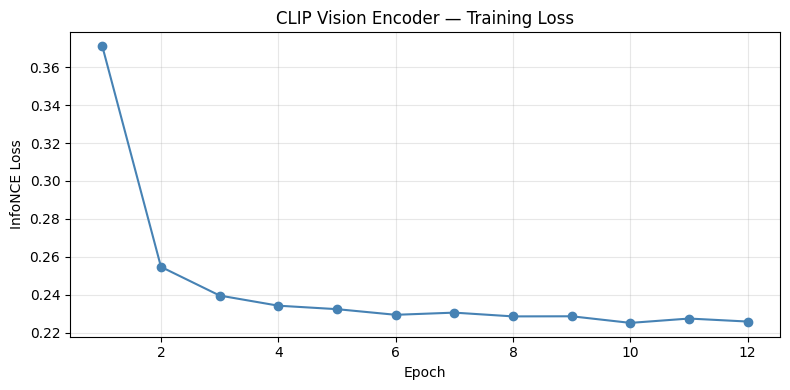

Loss curve saved!


In [10]:
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(loss_history)+1), loss_history, marker='o', color='steelblue')
plt.xlabel('Epoch')
plt.ylabel('InfoNCE Loss')
plt.title('CLIP Vision Encoder — Training Loss')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('/kaggle/working/loss_curve.png', dpi=100)
plt.show()
print('Loss curve saved!')

## 9. Rebuild Gallery Index with Fine-Tuned CLIP (Config C)

In [11]:
!pip uninstall -y faiss faiss-gpu
!pip install faiss-cpu --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 49.7 MB/s eta 0:00:00


In [12]:
import faiss

# Load gallery data
gal_table  = full_table[full_table['split'] == 'gallery'].reset_index(drop=True)
gal_table['img_path'] = gal_table['crop_path'].apply(translate_path)
gal_table['on_disk']  = gal_table['img_path'].apply(
    lambda p: os.path.exists(p) if isinstance(p, str) else False
)
valid_gal = gal_table[gal_table['on_disk']].reset_index(drop=True)

with open(os.path.join(CAPTIONS_DIR, 'gallery_captions.json')) as fh:
    gal_captions = json.load(fh)

# Load best fine-tuned weights
clip_net.load_state_dict(torch.load('/kaggle/working/full_clip_finetuned.pt'))
clip_net.eval()
VEC_DIM = clip_net.config.projection_dim

ENCODE_BATCH = 64
n_gal        = len(valid_gal)
ft_img_vecs  = np.zeros((n_gal, VEC_DIM), dtype=np.float32)
ft_txt_vecs  = np.zeros((n_gal, VEC_DIM), dtype=np.float32)

print(f'Re-encoding {n_gal:,} gallery images + captions with fine-tuned CLIP...')

for s in tqdm(range(0, n_gal, ENCODE_BATCH), desc='Re-encoding'):
    chunk = valid_gal.iloc[s : s + ENCODE_BATCH]

    imgs, ok_idx = [], []
    for i, (_, row) in enumerate(chunk.iterrows()):
        try:
            imgs.append(Image.open(row['img_path']).convert('RGB'))
            ok_idx.append(i)
        except Exception: pass
    if imgs:
        inp = clip_proc(images=imgs, return_tensors='pt', padding=True).to(GPU)
        with torch.no_grad():
            vis_out   = clip_net.vision_model(pixel_values=inp['pixel_values'])
            projected = clip_net.visual_projection(vis_out.pooler_output)
            projected = projected / projected.norm(dim=-1, keepdim=True)
        for li, gi in enumerate(ok_idx):
            ft_img_vecs[s + gi] = projected[li].cpu().numpy()

    caps = [gal_captions.get(row['image_name'], 'a clothing item') for _, row in chunk.iterrows()]
    t_inp = clip_proc(text=caps, return_tensors='pt', padding=True, truncation=True, max_length=77).to(GPU)
    with torch.no_grad():
        t_raw  = clip_net.get_text_features(**t_inp)
        t_vecs = t_raw.pooler_output if hasattr(t_raw, 'pooler_output') and not isinstance(t_raw, torch.Tensor) else t_raw
        t_vecs = t_vecs / t_vecs.norm(dim=-1, keepdim=True)
    ft_txt_vecs[s : s + len(caps)] = t_vecs.cpu().numpy()

print('Re-encoding complete!')

# Build Config C indexes for two beta values
for beta in [0.7, 0.5]:
    b_tag = f'b{int(beta*10):02d}'
    fused = BLEND_BETA * ft_img_vecs + (1 - BLEND_BETA) * ft_txt_vecs
    norms = np.linalg.norm(fused, axis=-1, keepdims=True)
    fused = fused / np.maximum(norms, 1e-8)

    np.save(f'/kaggle/working/gallery_vectors_C_{b_tag}.npy', fused)
    ci = faiss.IndexFlatIP(VEC_DIM)
    ci.add(fused.astype(np.float32))
    faiss.write_index(ci, f'/kaggle/working/idx_C_{b_tag}.bin')
    print(f'Config C index saved: beta={beta}, vectors={ci.ntotal:,}')

Re-encoding 12,612 gallery images + captions with fine-tuned CLIP...


Re-encoding: 100%|██████████| 198/198 [01:52<00:00,  1.76it/s]


Re-encoding complete!
Config C index saved: beta=0.7, vectors=12,612
Config C index saved: beta=0.5, vectors=12,612


## 10. Summary

In [13]:
print('=' * 60)
print('   CLIP FINE-TUNING + CONFIG C INDEXING COMPLETE')
print('=' * 60)
print(f'  CLIP checkpoint : {CLIP_CKPT}')
print(f'  Epochs trained  : {NUM_EPOCHS}')
print(f'  Best loss       : {top_loss:.4f}')
print(f'  Blocks unfrozen : last {UNFREEZE_LAST}')
print(f'  Text encoder    : FROZEN throughout')
print()
print('  Output files:')
for fn in sorted(os.listdir('/kaggle/working')):
    if fn.endswith(('.pt', '.bin', '.npy', '.png')):
        sz = os.path.getsize(f'/kaggle/working/{fn}') / 1e6
        print(f'    {fn}  ({sz:.1f} MB)')
print()
print('  Next: save output as Kaggle dataset, then run evaluation-c notebook')
print('=' * 60)

   CLIP FINE-TUNING + CONFIG C INDEXING COMPLETE
  CLIP checkpoint : openai/clip-vit-base-patch32
  Epochs trained  : 12
  Best loss       : 0.2252
  Blocks unfrozen : last 4
  Text encoder    : FROZEN throughout

  Output files:
    full_clip_finetuned.pt  (605.3 MB)
    gallery_vectors_C_b05.npy  (25.8 MB)
    gallery_vectors_C_b07.npy  (25.8 MB)
    idx_C_b05.bin  (25.8 MB)
    idx_C_b07.bin  (25.8 MB)
    loss_curve.png  (0.0 MB)
    vision_finetuned.pt  (349.9 MB)

  Next: save output as Kaggle dataset, then run evaluation-c notebook
